## Module 4: Check In #3

## Team Members:
Roy Chen

Theresa Breckley

## Project Title:
### Apoptosis-Related Gene Expression Patterns in Breast Cancer and Their Relationship to Tumor Stage

## Project Goal:
This project aims to investigate whether apoptosis-related gene expression patterns can distinguish subgroups of breast cancer tumors and determine whether those patterns can help predict tumor stage.

We focus on the cancer hallmark **resisting apoptosis** because cancer cells that avoid programmed cell death can survive despite DNA damage, abnormal growth signals, or other cellular stress. We use RNA sequencing data from TCGA to analyze apoptosis-related genes in breast cancer samples, first using dimensionality reduction and clustering, then using a supervised classification model to predict tumor stage group.

# Check In #1 & #2

## Disease Background:
*Pick a hallmark to focus on, and figure out what genes you are interested in researching based on that decision. Then fill out the information below.*

* Cancer hallmark focus: Resisting apoptosis (evading programmed cell death) 

* Overview of hallmark: 

Apoptosis is a programmed cell death process that removes damaged, or unnecessary cells to maintain healthy tissue function. In normal cells, apoptosis is tightly regulated through cell cycle checkpoints, particularly at the G1, G2, and G0 phases, which act as check points to detect any abnormalities in cell reproduction.  

At the G1 checkpoint, cells assess DNA integrity before replication. If any damage is detected, the tumor suppressor protein p53 can pause the cell cycle to allow repair or trigger apoptosis. The G2 checkpoint serves as a second control point after DNA replication, ensuring that genetic material has been accurately copied; cells with unrepaired damage are triggered to undergo apoptosis. In contrast, the G0 phase represents a resting state where cells exit the cycle to prevent unnecessary division, helping maintain tissue stability.

Cancer cells acquire the ability to resist apoptosis by disrupting these checkpoints. Mutations in key regulatory genes, such as TP53, allow cells with damaged DNA to bypass G1 and G2 control mechanisms and continue dividing uncontrollably. 



* Prevalence & incidence

Cancer is one of the leading causes of death worldwide and a major public health concern. In the United States, the most commonly diagnosed cancers include breast, prostate, lung, and colorectal cancer with lung cancer in the highest mortality rate due to its aggressive progression and late-stage detection.

Cancer incidence increases significantly with age, as mutations accumulate over time. Globally, cancer rates are rising due to population aging, environmental exposures, and lifestyle factors.


* Risk factors (genetic, lifestyle) & Societal determinants

Cancer risk can a rise from a combination factors such as genetic, environmental, and lifestyle factors. mutations in tumor suppressor genes like P53 and oncogenes, which increase susceptibility to cancer by disrupting normal cell cycle regulation and apoptosis can increase the chance of recieving cancer. While lifestyle factors such as smoking, poor diet, physical inactivity, alcohol consumption, and exposure to UV radiation and air pollution are major contributors to cancer development.

People in more underdeveloped regions often have a higher cancer rate compare to more developed regions do due lack of access to health care, early screening and limited access to preventive care and treatment often experience higher mortality rates.

* Standard of care treatments (& reimbursement) 

Current standard cancer treatments include surgery, chemotherapy, radiation therapy, targeted therapy, and immunotherapy:

- **Surgery** removes localized tumors  
- **Chemotherapy** targets rapidly dividing cellss by inducing damage to the DNA   
- **Radiation therapy** damages DNA in cancer cells to trigger apotosis 
- **Targeted therapy** focuses on target certain cell 
- **Immunotherapy** enhances the immune system’s ability to recognize and target cancer cells  

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology):

Apoptosis is controlled by a balance between pro apoptotic and anti apoptotic signals, 
Pro apoptotic (e.g., BAX, BAK) promote cell death while Anti apoptotic (e.g., BCL-2) prevent apoptosis.

In cancer, these pathways are often disrupted for example the loss of TP53 function prevents apoptosis while an overexpression of BCL-2 blocks cell death, allowing  abnormal cells to survive. These changes enable cancer cells to evade death signals, continue proliferating, and resist therapies that rely on apoptosis.

*Will you be focusing on a single cancer type or looking across cancer types? Depending on your decision, update this section to include relevant information about the disease at the appropriate level of detail. Regardless, each bullet point should be filled in. If you are looking at multiple cancer types, you should investigate differences between the types (e.g. what is the most prevalent cancer type? What type has the highest mortality rate?) and similarities (e.g. what sorts of treatments exist across the board for cancer patients? what is common to all cancers in terms of biological mechanisms?)*

## Data-Set: 

The dataset used in this project is derived from The Cancer Genome Atlas (TCGA) and includes RNA sequencing (RNA-seq) data along with clinical metadata. For this analysis, we will focus on the training dataset.

The gene expression data (TRAINING_SET_GSE62944_subsample_log2TPM.csv) is organized as a matrix of genes × samples, where each value represents the expression level of a gene in a tumor sample. These values are given as log₂(TPM + 1), where TPM (Transcripts Per Million) normalizes for gene length and sequencing depth.

The metadata file (TRAINING_SET_GSE62944_metadata.csv) contains clinical information for each sample, including cancer type, tumor stage, and other patient characteristics.

By combining gene expression data with metadata, we can analyze how apoptosis-related gene expression varies across breast cancer samples and how it relates to tumor progression and clinical outcomes.

The genes selected for this analysis are associated with apoptosis pathways. These include:

* TP53 (tumor suppressor gene involved in DNA damage response)
* BAX (pro-apoptotic regulator that promotes cell death)
* BCL2 (anti-apoptotic protein that inhibits cell death)
* CASP3 (caspase involved in execution of apoptosis)

These genes were chosen because they play key roles in regulating programmed cell death and are commonly dysregulated in breast cancer.

## Check-in #2 Analysis Plan

For Check-in #2, we need to show that:
1. the training data and metadata were subsetted and cleaned,
2. PCA was used to explore the data,
3. clustering and/or UMAP was used and visualized,
4. the analysis is thoughtfully explained, and
5. there is a clear plan for a supervised learning model.

For this project, we focus on **breast cancer (BRCA)** and the hallmark **resisting apoptosis**.  
Our working question is:

**Can apoptosis-related gene expression distinguish subgroups of breast cancer tumors, and can these expression patterns help predict tumor stage?**

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

sns.set_theme(style="whitegrid")

# -----------------------------
# File paths
# -----------------------------
# Update these paths if your files are stored somewhere else on your computer.
# This notebook assumes the metadata and expression file are in the same folder
# or in a nearby data/ folder.

possible_metadata_paths = [
    Path("TRAINING_SET_GSE62944_metadata.csv"),
    Path("data/TRAINING_SET_GSE62944_metadata.csv"),
    Path("../data/TRAINING_SET_GSE62944_metadata.csv"),
]

possible_expression_paths = [
    Path("TRAINING_SET_GSE62944_subsample_log2TPM.csv"),
    Path("data/TRAINING_SET_GSE62944_subsample_log2TPM.csv"),
    Path("../data/TRAINING_SET_GSE62944_subsample_log2TPM.csv"),
]

possible_validation_metadata_paths = [
    Path("VALIDATION_SET_GSE62944_metadata.csv"),
    Path("data/VALIDATION_SET_GSE62944_metadata.csv"),
    Path("../data/VALIDATION_SET_GSE62944_metadata.csv"),
]

possible_validation_expression_paths = [
    Path("VALIDATION_SET_GSE62944_subsample_log2TPM.csv"),
    Path("data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv"),
    Path("../data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv"),
]


def first_existing_path(path_list):
    for p in path_list:
        if p.exists():
            return p
    return None

metadata_path = first_existing_path(possible_metadata_paths)
expression_path = first_existing_path(possible_expression_paths)

print("Metadata path found:", metadata_path)
print("Expression path found:", expression_path)

if metadata_path is None:
    raise FileNotFoundError("Could not find TRAINING_SET_GSE62944_metadata.csv. Update possible_metadata_paths.")
if expression_path is None:
    raise FileNotFoundError("Could not find TRAINING_SET_GSE62944_subsample_log2TPM.csv. Update possible_expression_paths.")

Metadata path found: ..\data\TRAINING_SET_GSE62944_metadata.csv
Expression path found: ..\data\TRAINING_SET_GSE62944_subsample_log2TPM.csv


## Load the Training Data

The project instructions emphasize focusing on the **training set** at this stage.  
The expression matrix is organized as **genes × samples**, while the metadata is organized as **samples × clinical features**.

In [2]:
# Load metadata and expression data
metadata_df = pd.read_csv(metadata_path, index_col=0)
data = pd.read_csv(expression_path, index_col=0)

print("Expression data shape (genes x samples):", data.shape)
print("Metadata shape (samples x features):", metadata_df.shape)
print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Expression data shape (genes x samples): (15716, 1802)
Metadata shape (samples x features): (1802, 29)

Metadata columns:
['cancer_type', 'bcr_patient_barcode', 'gender', 'race', 'ethnicity', 'age_at_diagnosis', 'ajcc_pathologic_tumor_stage', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_tumor_pathologic_pt', 'tumor_status', 'histologic_diagnosis', 'history_other_malignancy', 'history_thyroid_disease', 'history_thyroid_disease_other', 'history_reflux_disease_indicator', 'history_hormonal_contraceptives_use', 'pregnancies_count_miscarriage', 'jewish_religion_heritage_indicator', 'tobacco_smoking_age_started', 'family_history_cancer_type', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']


## Subset to Breast Cancer (BRCA) and Apoptosis Genes

To keep the project focused, we subset the dataset to **breast cancer samples** and to a hallmark-specific **apoptosis gene set**.

This gene list includes both pro-apoptotic and anti-apoptotic regulators, caspases, and key pathway members that are biologically relevant to cancer cells resisting programmed cell death.

In [3]:
# Subset metadata to breast cancer
brca_metadata = metadata_df[metadata_df["cancer_type"] == "BRCA"].copy()
print("BRCA metadata shape:", brca_metadata.shape)

# Apoptosis / resisting apoptosis gene set
desired_gene_list = [
    "BCL2", "BCL2L1", "MCL1", "BAX", "BAK1",
    "TP53", "CASP3", "CASP8", "CASP9",
    "FAS", "FADD", "XIAP", "BIRC5",
    "BAD", "BID", "BBC3", "PMAIP1"
]

available_genes = [gene for gene in desired_gene_list if gene in data.index]
missing_genes = [gene for gene in desired_gene_list if gene not in data.index]

print("Number of requested genes:", len(desired_gene_list))
print("Number of genes found in dataset:", len(available_genes))
print("Genes found:", available_genes)
print("Missing genes:", missing_genes)

# Subset expression data to BRCA samples and apoptosis genes
brca_sample_ids = brca_metadata.index.intersection(data.columns)
brca_data = data.loc[available_genes, brca_sample_ids]

print("\nBRCA expression subset shape (genes x BRCA samples):", brca_data.shape)
brca_data.head()

BRCA metadata shape: (80, 29)
Number of requested genes: 17
Number of genes found in dataset: 17
Genes found: ['BCL2', 'BCL2L1', 'MCL1', 'BAX', 'BAK1', 'TP53', 'CASP3', 'CASP8', 'CASP9', 'FAS', 'FADD', 'XIAP', 'BIRC5', 'BAD', 'BID', 'BBC3', 'PMAIP1']
Missing genes: []

BRCA expression subset shape (genes x BRCA samples): (17, 80)


,TCGA-E9-A1NI-01A-11R-A14D-07,TCGA-E2-A1LK-01A-21R-A14D-07,TCGA-BH-A0B2-01A-11R-A10J-07,TCGA-E2-A107-01A-11R-A10J-07,TCGA-LL-A5YN-01A-11R-A28M-07,TCGA-BH-A0DQ-01A-11R-A084-07,TCGA-D8-A73X-01A-11R-A32P-07,TCGA-AR-A0TP-01A-11R-A084-07,TCGA-E2-A1IF-01A-11R-A144-07,TCGA-EW-A6SD-01A-12R-A33J-07,...,TCGA-D8-A1JA-01A-11R-A13Q-07,TCGA-A2-A0D0-01A-11R-A00Z-07,TCGA-A8-A07B-01A-11R-A00Z-07,TCGA-C8-A275-01A-21R-A16F-07,TCGA-AO-A1KQ-01A-11R-A13Q-07,TCGA-E9-A5UP-01A-11R-A28M-07,TCGA-AR-A24T-01A-11R-A169-07,TCGA-D8-A1XB-01A-11R-A14D-07,TCGA-E9-A245-01A-22R-A16F-07,TCGA-WT-AB44-01A-11R-A41B-07
BCL2,5.248282,0.985832,5.784362,4.152444,3.692885,4.763121,5.221591,5.376440,4.050835,1.936183,...,1.693603,1.996426,5.779014,2.672941,5.405569,5.532695,5.958578,6.085538,6.243730,1.873949
BCL2L1,7.818040,6.874837,7.115444,7.566785,6.954511,7.408560,7.460900,6.024670,6.833883,7.256705,...,7.514368,6.689359,6.784440,7.055031,7.299693,8.759745,7.486974,7.529951,6.777458,6.381661
MCL1,7.816182,8.140580,8.165650,8.071209,7.278051,8.035222,8.193623,7.856121,8.412290,8.395989,...,9.078687,8.175704,8.279657,8.363384,7.513230,8.424985,8.756147,8.547165,7.503071,8.404597
BAX,6.720700,7.189939,6.504814,7.466535,7.662465,6.634294,6.585344,5.994697,7.414525,6.308539,...,5.301869,6.917972,6.257364,6.167569,7.180470,7.320232,5.802379,6.468790,5.992391,6.350984
BAK1,4.584133,5.334564,4.855286,4.845804,5.442022,5.610309,4.346540,4.705020,4.831672,4.301206,...,4.254277,5.583720,4.708609,5.048889,4.169633,4.340381,4.749268,4.740960,3.371286,3.386362


## Clean Key Metadata Fields

Our future supervised learning target will be **tumor stage**.  
The metadata column that stores stage is:

**`ajcc_pathologic_tumor_stage`**

To make the eventual classification problem cleaner, we convert the original stage labels into a simpler binary grouping:

- **Early stage** = Stage I or Stage II  
- **Late stage** = Stage III or Stage IV

In [4]:
# Keep only metadata rows that match the expression matrix
brca_metadata = brca_metadata.loc[brca_sample_ids].copy()

# Make age numeric for cleaner summaries
brca_metadata["age_at_diagnosis"] = pd.to_numeric(
    brca_metadata["age_at_diagnosis"], errors="coerce"
)

# Inspect tumor stage values
print(brca_metadata["ajcc_pathologic_tumor_stage"].value_counts(dropna=False))

def simplify_stage(stage_value):
    """
    Convert AJCC pathologic tumor stage into a binary classification target.

    Early = Stage I or Stage II
    Late = Stage III or Stage IV

    Important: we check Stage IV and Stage III before Stage I so that
    labels like 'Stage III' are not accidentally counted as Stage I.
    """
    if pd.isna(stage_value):
        return np.nan

    stage_str = str(stage_value).upper().strip()

    if "STAGE IV" in stage_str or stage_str.startswith("IV"):
        return "Late"
    elif "STAGE III" in stage_str or stage_str.startswith("III"):
        return "Late"
    elif "STAGE II" in stage_str or stage_str.startswith("II"):
        return "Early"
    elif "STAGE I" in stage_str or stage_str.startswith("I"):
        return "Early"
    else:
        return np.nan

brca_metadata["stage_group"] = brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nStage group counts:")
print(brca_metadata["stage_group"].value_counts(dropna=False))

print("\nAge summary:")
print(brca_metadata["age_at_diagnosis"].describe())


ajcc_pathologic_tumor_stage
Stage IIA          23
Stage IIB          14
Stage IIIA         11
Stage I             7
Stage IA            7
Stage IIIC          5
NaN                 4
Stage IV            4
Stage IIIB          3
Stage IB            1
[Not Available]     1
Name: count, dtype: int64

Stage group counts:
stage_group
Early    52
Late     23
NaN       5
Name: count, dtype: int64

Age summary:
count    76.000000
mean     59.078947
std      12.609798
min      36.000000
25%      48.750000
50%      58.500000
75%      69.250000
max      84.000000
Name: age_at_diagnosis, dtype: float64


## Prepare the Matrix for PCA

Scikit-learn expects the matrix as **samples × features**, so we transpose the expression data and standardize the gene expression values before PCA.

Standardization is important here because genes can have different expression ranges, and PCA is sensitive to scale.

In [5]:
# Transpose so rows = samples and columns = genes
X = brca_data.T

# Standardize the expression values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
pca_df = pca_df.join(brca_metadata)

# Add one key gene for coloring
if "BCL2" in X.columns:
    pca_df["BCL2_expression"] = X["BCL2"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio:
[0.1987766  0.15712808]


,PC1,PC2,cancer_type,bcr_patient_barcode,gender,race,ethnicity,age_at_diagnosis,ajcc_pathologic_tumor_stage,ajcc_nodes_pathologic_pn,...,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,stage_group,BCL2_expression
TCGA-E9-A1NI-01A-11R-A14D-07,-0.246504,0.978967,BRCA,TCGA-E9-A1NI,FEMALE,WHITE,NOT HISPANIC OR LATINO,51.0,Stage IIA,N0,...,0.0,300.0,0.0,300.0,0.0,300.0,0.0,300.0,Early,5.248282
TCGA-E2-A1LK-01A-21R-A14D-07,-5.239930,-1.590538,BRCA,TCGA-E2-A1LK,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,84.0,Stage IIIC,N3a,...,1.0,266.0,1.0,266.0,1.0,155.0,1.0,155.0,Late,0.985832
TCGA-BH-A0B2-01A-11R-A10J-07,0.263982,-0.156312,BRCA,TCGA-BH-A0B2,FEMALE,WHITE,NOT HISPANIC OR LATINO,43.0,Stage I,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early,5.784362
TCGA-E2-A107-01A-11R-A10J-07,-1.693936,1.653981,BRCA,TCGA-E2-A107,FEMALE,WHITE,NOT HISPANIC OR LATINO,54.0,Stage IIIA,N2a,...,0.0,1047.0,0.0,1047.0,0.0,1047.0,0.0,1047.0,Late,4.152444
TCGA-LL-A5YN-01A-11R-A28M-07,-3.004212,1.201851,BRCA,TCGA-LL-A5YN,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,46.0,Stage IIA,N0 (i-),...,0.0,447.0,0.0,447.0,0.0,447.0,0.0,447.0,Early,3.692885


## PCA Visualization

The first PCA plot is colored by **tumor stage group** to see whether apoptosis-related expression patterns separate earlier vs later tumors.

The second PCA plot is colored by **BCL2 expression**, since BCL2 is a major anti-apoptotic gene and a biologically meaningful marker for this hallmark.

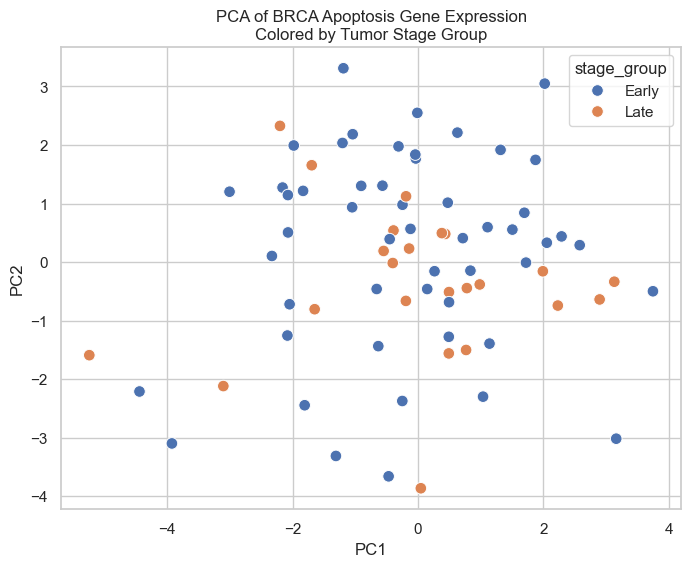

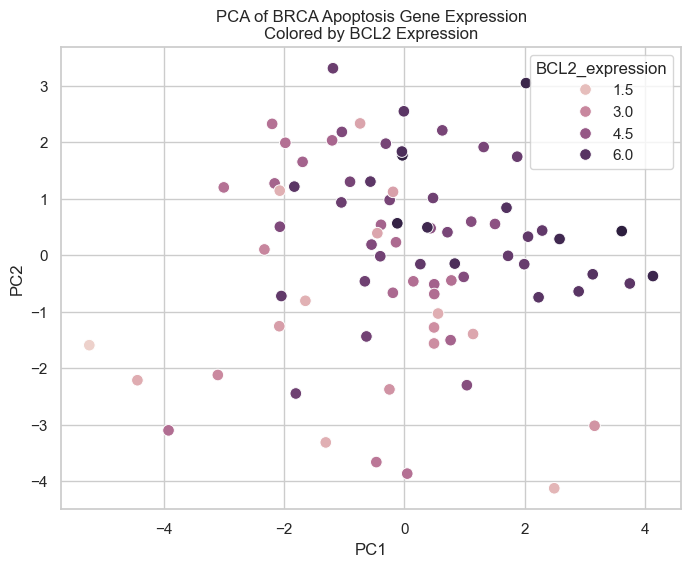

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="stage_group",
    s=70
)
plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by Tumor Stage Group")
plt.show()

if "BCL2_expression" in pca_df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="BCL2_expression",
        s=70
    )
    plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by BCL2 Expression")
    plt.show()

### PCA Interpretation

These PCA plots help us visualize whether breast cancer tumors vary in apoptosis-related expression in a structured way.  
If samples separate by stage group or by BCL2 expression, that suggests apoptosis signaling may be associated with disease progression or tumor subtype differences in BRCA.

## K-means Clustering

For the second required unsupervised step, we use **K-means clustering** on the apoptosis gene expression matrix.

This is a simple first clustering method that can reveal whether there are distinct subgroups of BRCA tumors based on apoptosis-related gene expression patterns.

c:\Users\15712\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


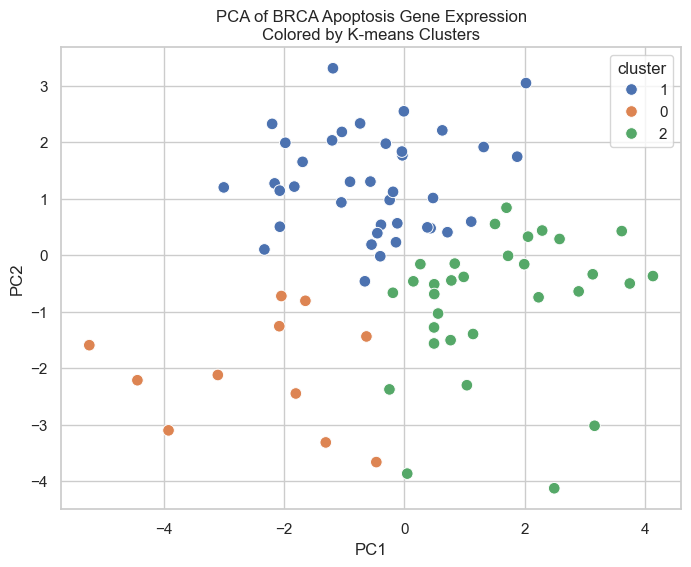

Cluster counts:
cluster
1    38
2    31
0    11
Name: count, dtype: int64


In [7]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca_df["cluster"] = clusters.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=70
)
plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by K-means Clusters")
plt.show()

print("Cluster counts:")
print(pca_df["cluster"].value_counts())

### Clustering Interpretation

K-means clustering groups tumors with similar apoptosis-related expression patterns.  
If the clusters appear visually separated on the PCA plot, that suggests the tumors may contain biologically meaningful subgroups.  
In later work, we can compare these clusters to stage or other metadata variables to understand what the clusters may represent.

## Summary of Check-in #2 Progress

So far, this analysis has:

- subsetted the **training dataset** to **breast cancer (BRCA)** samples,
- selected a biologically relevant **apoptosis gene set**,
- cleaned and summarized the **tumor stage metadata**,
- used **PCA** to visualize variation in apoptosis-related gene expression, and
- applied **K-means clustering** to look for possible tumor subgroups.

This satisfies the main goals of Check-in #2 by showing data cleaning/subsetting, PCA exploration, and an additional unsupervised method with visualization.

## Plan for the Supervised Learning Model

For the next step of the project, we plan to use a **logistic regression classification model** to predict **tumor stage group (Early vs Late)** from apoptosis-related gene expression.

This is a good first supervised learning model because:

1. it is designed for **classification** problems,
2. it is relatively simple and interpretable,
3. it works well as a baseline model for high-dimensional biological data, and
4. it allows us to evaluate whether apoptosis-related genes contain predictive information about disease progression.

If the stage labels are too imbalanced or too sparse after cleaning, we may also compare this with another simple classifier later, but logistic regression is the best first choice for this project.

# Check-in #3: Supervised Machine Learning Model

For Check-in #3, we apply a supervised machine learning model to the **training data**, evaluate how well it performs on both the **training data** and the **validation data**, and compare in-sample vs. out-of-sample performance. We do **not** use the test set in this check-in.

Our supervised learning task is:

**Can apoptosis-related gene expression predict breast cancer tumor stage group?**

- Input features: apoptosis-related gene expression values  
- Target variable: tumor stage group  
- Model: logistic regression  
- Classes:
  - Early = Stage I or Stage II
  - Late = Stage III or Stage IV


In [8]:
# -----------------------------
# Prepare training data for supervised learning
# -----------------------------

# Keep only samples with a usable stage group
train_valid_samples = brca_metadata.dropna(subset=["stage_group"]).index

# X_train: samples x apoptosis genes
X_train = brca_data.T.loc[train_valid_samples].copy()

# y_train: early vs late tumor stage group
y_train = brca_metadata.loc[train_valid_samples, "stage_group"].copy()

print("Training feature matrix shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("\nTraining class balance:")
print(y_train.value_counts())

# Scale the gene expression features using only the training data
ml_scaler = StandardScaler()
X_train_scaled = ml_scaler.fit_transform(X_train)

# Fit logistic regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

# Predict on the same training data to estimate in-sample performance
y_train_pred = log_reg_model.predict(X_train_scaled)
y_train_scores = log_reg_model.predict_proba(X_train_scaled)[:, list(log_reg_model.classes_).index("Late")]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)

print("\nTraining accuracy:", train_accuracy)
print("Training balanced accuracy:", train_balanced_accuracy)

print("\nTraining classification report:")
print(classification_report(y_train, y_train_pred, zero_division=0))


Training feature matrix shape: (75, 17)
Training target shape: (75,)

Training class balance:
stage_group
Early    52
Late     23
Name: count, dtype: int64

Training accuracy: 0.7866666666666666
Training balanced accuracy: 0.7127926421404682

Training classification report:
              precision    recall  f1-score   support

       Early       0.81      0.90      0.85        52
        Late       0.71      0.52      0.60        23

    accuracy                           0.79        75
   macro avg       0.76      0.71      0.73        75
weighted avg       0.78      0.79      0.78        75



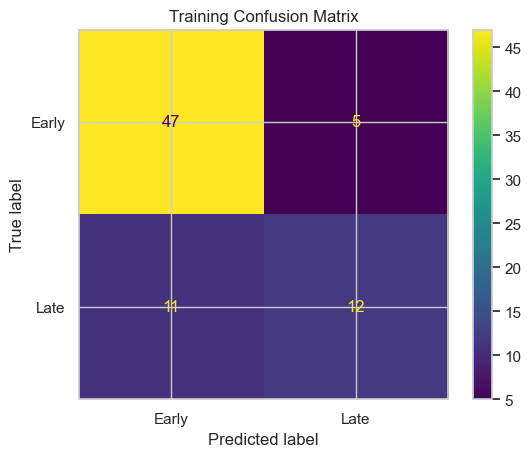

In [9]:
# Confusion matrix for training data
train_cm = confusion_matrix(y_train, y_train_pred, labels=log_reg_model.classes_)

train_disp = ConfusionMatrixDisplay(
    confusion_matrix=train_cm,
    display_labels=log_reg_model.classes_
)

train_disp.plot()
plt.title("Training Confusion Matrix")
plt.show()


## Validation Dataset Evaluation

The validation dataset is used to estimate **out-of-sample performance**, meaning how well the model performs on new data that was not used to fit the model.

The same BRCA subset, apoptosis gene list, stage-group cleaning, and feature scaling approach are applied to the validation data. The scaler and model are **fit only on the training data** and then applied to validation data.


In [10]:
# -----------------------------
# Load validation data
# -----------------------------
validation_metadata_path = first_existing_path(possible_validation_metadata_paths)
validation_expression_path = first_existing_path(possible_validation_expression_paths)

print("Validation metadata path found:", validation_metadata_path)
print("Validation expression path found:", validation_expression_path)

if validation_metadata_path is None:
    raise FileNotFoundError("Could not find VALIDATION_SET_GSE62944_metadata.csv. Update possible_validation_metadata_paths.")
if validation_expression_path is None:
    raise FileNotFoundError("Could not find VALIDATION_SET_GSE62944_subsample_log2TPM.csv. Update possible_validation_expression_paths.")

validation_metadata_df = pd.read_csv(validation_metadata_path, index_col=0)
validation_data = pd.read_csv(validation_expression_path, index_col=0)

print("Validation expression data shape (genes x samples):", validation_data.shape)
print("Validation metadata shape (samples x features):", validation_metadata_df.shape)

# Subset validation data to BRCA samples
validation_brca_metadata = validation_metadata_df[validation_metadata_df["cancer_type"] == "BRCA"].copy()
validation_brca_sample_ids = validation_brca_metadata.index.intersection(validation_data.columns)

validation_brca_metadata = validation_brca_metadata.loc[validation_brca_sample_ids].copy()

# Apply the same stage cleaning function
validation_brca_metadata["stage_group"] = validation_brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nValidation stage group counts:")
print(validation_brca_metadata["stage_group"].value_counts(dropna=False))

# Use the same genes that were available in the training data
validation_available_genes = [gene for gene in available_genes if gene in validation_data.index]
validation_missing_genes = [gene for gene in available_genes if gene not in validation_data.index]

print("\nValidation genes found:", validation_available_genes)
print("Validation genes missing:", validation_missing_genes)

if validation_missing_genes:
    raise ValueError("Some training genes are missing from validation data. Check gene names before continuing.")

validation_brca_data = validation_data.loc[available_genes, validation_brca_sample_ids]

# Keep only validation samples with usable stage group
validation_valid_samples = validation_brca_metadata.dropna(subset=["stage_group"]).index

X_validation = validation_brca_data.T.loc[validation_valid_samples].copy()
y_validation = validation_brca_metadata.loc[validation_valid_samples, "stage_group"].copy()

# Make sure validation columns are in the exact same order as training columns
X_validation = X_validation[X_train.columns]

print("\nValidation feature matrix shape:", X_validation.shape)
print("Validation target shape:", y_validation.shape)
print("\nValidation class balance:")
print(y_validation.value_counts())

# Transform validation data with the scaler fit on training data
X_validation_scaled = ml_scaler.transform(X_validation)

# Predict validation labels and scores
y_validation_pred = log_reg_model.predict(X_validation_scaled)
y_validation_scores = log_reg_model.predict_proba(X_validation_scaled)[:, list(log_reg_model.classes_).index("Late")]

validation_accuracy = accuracy_score(y_validation, y_validation_pred)
validation_balanced_accuracy = balanced_accuracy_score(y_validation, y_validation_pred)

print("\nValidation accuracy:", validation_accuracy)
print("Validation balanced accuracy:", validation_balanced_accuracy)

print("\nValidation classification report:")
print(classification_report(y_validation, y_validation_pred, zero_division=0))


Validation metadata path found: ..\data\VALIDATION_SET_GSE62944_metadata.csv
Validation expression path found: ..\data\VALIDATION_SET_GSE62944_subsample_log2TPM.csv
Validation expression data shape (genes x samples): (15716, 1360)
Validation metadata shape (samples x features): (1360, 29)

Validation stage group counts:
stage_group
Early    56
Late     22
NaN       2
Name: count, dtype: int64

Validation genes found: ['BCL2', 'BCL2L1', 'MCL1', 'BAX', 'BAK1', 'TP53', 'CASP3', 'CASP8', 'CASP9', 'FAS', 'FADD', 'XIAP', 'BIRC5', 'BAD', 'BID', 'BBC3', 'PMAIP1']
Validation genes missing: []

Validation feature matrix shape: (78, 17)
Validation target shape: (78,)

Validation class balance:
stage_group
Early    56
Late     22
Name: count, dtype: int64

Validation accuracy: 0.5769230769230769
Validation balanced accuracy: 0.4707792207792208

Validation classification report:
              precision    recall  f1-score   support

       Early       0.70      0.71      0.71        56
        Late

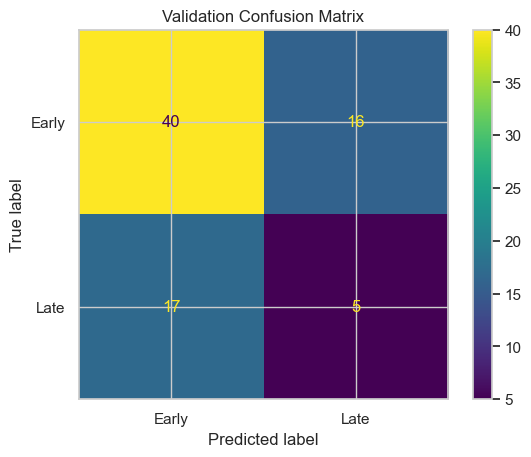

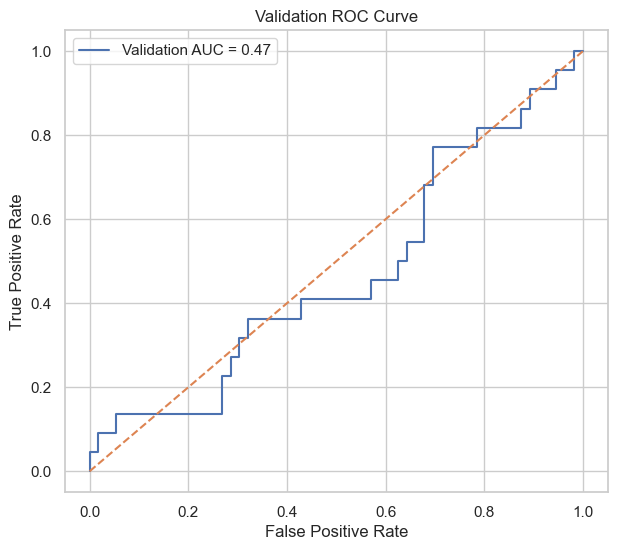

Validation AUC: 0.46834415584415584


In [11]:
# Confusion matrix for validation data
validation_cm = confusion_matrix(y_validation, y_validation_pred, labels=log_reg_model.classes_)

validation_disp = ConfusionMatrixDisplay(
    confusion_matrix=validation_cm,
    display_labels=log_reg_model.classes_
)

validation_disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

# ROC curve for validation data
# This is useful because logistic regression gives probability-like scores,
# so we can evaluate performance across possible thresholds.
if len(np.unique(y_validation)) == 2:
    y_validation_binary = (y_validation == "Late").astype(int)
    fpr, tpr, thresholds = roc_curve(y_validation_binary, y_validation_scores)
    validation_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"Validation AUC = {validation_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()

    print("Validation AUC:", validation_auc)
else:
    validation_auc = np.nan
    print("ROC curve was not created because the validation target does not contain both classes.")


,Dataset,Accuracy,Error,Balanced Accuracy,Balanced Error
0,Training,0.786667,0.213333,0.712793,0.287207
1,Validation,0.576923,0.423077,0.470779,0.529221


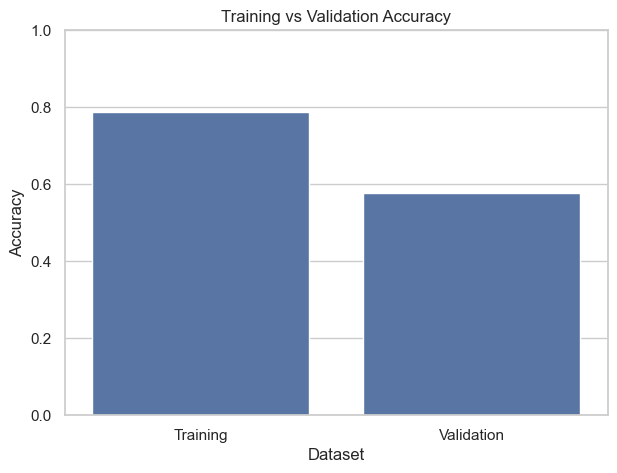

Training error: 0.21333333333333337
Validation error: 0.42307692307692313
Training balanced error: 0.2872073578595318
Validation balanced error: 0.5292207792207793

Model fit interpretation:
The model may be overfitting because training accuracy is much higher than validation accuracy.


In [12]:
# -----------------------------
# Compare in-sample and out-of-sample error
# -----------------------------

train_error = 1 - train_accuracy
validation_error = 1 - validation_accuracy

train_balanced_error = 1 - train_balanced_accuracy
validation_balanced_error = 1 - validation_balanced_accuracy

results_df = pd.DataFrame({
    "Dataset": ["Training", "Validation"],
    "Accuracy": [train_accuracy, validation_accuracy],
    "Error": [train_error, validation_error],
    "Balanced Accuracy": [train_balanced_accuracy, validation_balanced_accuracy],
    "Balanced Error": [train_balanced_error, validation_balanced_error]
})

display(results_df)

# Simple bar plot of training vs validation accuracy
plt.figure(figsize=(7, 5))
sns.barplot(data=results_df, x="Dataset", y="Accuracy")
plt.ylim(0, 1)
plt.title("Training vs Validation Accuracy")
plt.show()

print("Training error:", train_error)
print("Validation error:", validation_error)
print("Training balanced error:", train_balanced_error)
print("Validation balanced error:", validation_balanced_error)

# Basic interpretation helper
accuracy_gap = train_accuracy - validation_accuracy

if accuracy_gap > 0.15:
    model_fit_interpretation = "The model may be overfitting because training accuracy is much higher than validation accuracy."
elif train_accuracy < 0.60 and validation_accuracy < 0.60:
    model_fit_interpretation = "The model may be underfitting because both training and validation accuracy are low."
else:
    model_fit_interpretation = "The model appears reasonably fit as a first-pass baseline, but more validation is needed before drawing strong conclusions."

print("\nModel fit interpretation:")
print(model_fit_interpretation)


## Check-in #3 Interpretation 


The logistic regression model was trained using apoptosis-related gene expression from BRCA samples in the training dataset. The model predicted whether each tumor belonged to the **Early** or **Late** tumor stage group.

The model achieved a training accuracy of **0.786667** and a validation accuracy of **0.56923**. The training error was **0.213333**, while the validation error was **0.423777**.

Because the validation dataset was not used to fit the model, the validation performance gives a better estimate of how well the model may generalize to new samples. If the training accuracy is much higher than the validation accuracy, that suggests the model may be **overfit**. If both training and validation accuracy are low, that suggests the model may be **underfit**. If training and validation performance are reasonably similar and above a baseline level, the model may be performing reasonably well as a first-pass classifier.

The confusion matrix helps show which stage groups the model predicts correctly and where it makes mistakes. The ROC curve and AUC summarize how well the model separates Early vs. Late stage tumors across possible classification thresholds.

Overall, this model tests whether resisting-apoptosis gene expression contains predictive information about tumor stage in breast cancer. This first model is intentionally simple and interpretable, so it gives us a useful baseline before trying more complex machine learning methods.
